In [10]:
"""
Bat Wing Parametric Flight Model
=================================
Bioinspired Robotics Course Project

Couples the aerodynamics and geometry of a bat-inspired flapping wing
based on the Lagrangian framework from Ramezani et al. (IROS 2015).

Three primary design parameters:
  - membrane_stiffness  (k_m)  : N/m   -- how stiff the silicon wing membrane is
  - joint_stiffness     (k_j)  : N·m/rad -- torsional stiffness at wing joints
  - wing_area           (S)    : m²    -- total planform area of one wing

Output metric:
  - Cost of Transport (COT)  : J / (N·m)  = energy per unit weight per unit distance
                               COT = P_avg / (m * g * V_forward)

Aerodynamic model follows strip theory (Theodorsen / Goman-Khrabrov unsteady lift)
as described in the paper.  The Lagrangian equations of motion are integrated
numerically for a 7-DoF simplified wing over one or more flapping cycles.

Usage
-----
    python bat_wing_cot.py

or import and call `sweep_parameters()` for parameter studies.
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Tuple, Dict
import warnings
warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------------
# 1.  Wing & Robot Morphology
# ---------------------------------------------------------------------------

@dataclass
class WingParams:
    """
    Geometric and structural parameters of one wing.
    These are the three design variables you sweep.
    """
    membrane_stiffness: float = 50.0    # k_m  [N/m]   passive membrane restoring force
    joint_stiffness:    float = 0.01    # k_j  [N·m/rad] torsional spring at carpus joint
    wing_area:          float = 0.025   # S    [m²]    planform area of one wing

    # ---- derived geometry (scale with wing_area) --------------------------
    @property
    def span(self) -> float:
        """Half-wingspan b [m]. Scales as sqrt(S / AR)."""
        AR = 6.0  # aspect ratio (fixed, biologically motivated)
        return np.sqrt(self.wing_area * AR)

    @property
    def mean_chord(self) -> float:
        """Mean aerodynamic chord c [m]."""
        return self.wing_area / self.span


@dataclass
class RobotParams:
    """
    Fixed morphological parameters matching B2 / Rousettus aegyptiacus.
    """
    mass:           float = 0.08       # total mass  [kg]
    g:              float = 9.81       # gravity     [m/s²]
    flap_freq:      float = 10.0       # f*          [Hz]
    flap_amp:       float = np.deg2rad(68.0)  # phi_m  [rad]
    feather_amp:    float = 0.505      # theta*_m   [rad]
    feather_offset: float = 0.0        # theta_0 control input [rad]
    split_cycle:    float = np.deg2rad(859.43)  # delta* [rad/s]
    rho_air:        float = 1.225      # air density [kg/m³]
    V_inf:          float = 3.0        # forward flight speed [m/s]
    e_oswald:       float = 0.85       # Oswald efficiency







In [11]:
# ---------------------------------------------------------------------------
# 2.  Wing Kinematics  (Eq. 40-41 from paper)
# ---------------------------------------------------------------------------

def wing_kinematics(t: float, rp: RobotParams) -> Tuple[float, float, float, float]:
    """
    Return (q_Lx, q_Ly, q_Rx, q_Ry) — joint angles at time t.
    Follows the split-cycle parametrization rd(t) in Eq. 40-41.
    """
    f   = rp.flap_freq
    phi = rp.flap_amp
    Kp  = 0.52          # K*_phi  (shape parameter)
    th  = rp.feather_amp
    ts  = -0.0092       # theta*_s  (phase offset)
    t0  = rp.feather_offset
    d   = rp.split_cycle
    om  = 2 * np.pi * f
    Tp  = 1.0 / f

    # split-cycle psi(t)
    t_mod = t % Tp
    thresh = np.pi / (om - d)
    if t_mod < thresh:
        psi = (om - d) * t_mod
    else:
        psi = (om + om * d / (om - 2*d)) * t_mod + (-2*np.pi*d / (om - 2*d))

    scale = phi / np.arcsin(Kp)
    q_flap = scale * np.arcsin(Kp * np.sin(psi))
    q_feat = th * np.cos(om * t + ts)

    q_Lx = q_flap
    q_Ly = q_feat - t0
    q_Rx = q_flap
    q_Ry = -q_feat + t0
    return q_Lx, q_Ly, q_Rx, q_Ry


def wing_kinematics_dot(t: float, rp: RobotParams, dt: float = 1e-5) -> Tuple[float, float, float, float]:
    """Numerical time derivative of wing kinematics."""
    k1 = np.array(wing_kinematics(t - dt, rp))
    k2 = np.array(wing_kinematics(t + dt, rp))
    return tuple((k2 - k1) / (2 * dt))


In [12]:
# ---------------------------------------------------------------------------
# 3.  Strip-Theory Aerodynamics  (Eqs. 3-11 from paper)
# ---------------------------------------------------------------------------

def separation_point_ode(v: float, alpha_k: float, alpha_dot: float,
                          tau1: float = 0.05, tau2: float = 0.01,
                          v0: float = 0.5) -> float:
    """
    ODE for the separation point (Goman-Khrabrov model, Eq. 3).
    dv/dt = (v0*(alpha_k - tau2*alpha_dot) - v) / tau1
    """
    return (v0 * (alpha_k - tau2 * alpha_dot) - v) / tau1


def lift_coefficient(alpha_k: float, v: float) -> float:
    """Elemental lift coefficient Cl,k  (Eq. 5)."""
    return (np.pi / 2.0) * np.sin(alpha_k * (1.0 + v + 2.0 * np.sqrt(max(v, 0.0))))


def drag_coefficient(Cl: float, AR: float, Re: float, e: float) -> float:
    """Elemental drag coefficient  (Eq. 9)."""
    Re = max(Re, 1.0)
    Cd_profile = 0.89 / np.sqrt(Re)
    Cd_induced = Cl**2 / (np.pi * e * AR)
    return Cd_profile + Cd_induced


def elemental_aero_forces(
    alpha_k: float,
    alpha_dot: float,
    v_sep: float,
    v_perp: float,       # |V_perp|  component ⊥ to chord  [m/s]
    zeta_dot: float,     # transverse (plunge) velocity of the element [m/s]
    zeta_ddot: float,    # transverse acceleration
    ck: float,           # elemental chord  [m]
    xa: float,           # non-dim aerodynamic center offset (0.25 typically)
    wp: WingParams,
    rp: RobotParams,
) -> Tuple[float, float]:
    """
    Compute elemental lift [N/m] and drag [N/m] per unit span.
    Follows Eqs. 7-9.  Returns (dL, dD).
    """
    rho = rp.rho_air
    V   = rp.V_inf
    AR  = 6.0

    Cl = lift_coefficient(alpha_k, v_sep)
    Re = rho * V * ck / 1.81e-5        # chord Reynolds number

    # quasi-steady lift (Theodorsen approximation, Eq. 7 leading term)
    dL_qs = 0.5 * rho * v_perp**2 * ck * Cl

    # circulatory added-mass correction
    dL_am = (np.pi / 4.0) * rho * ck**2 * (
        zeta_ddot + V * alpha_dot - (xa - 0.25) * ck * 0.0
    )
    dL = dL_qs + dL_am

    Cd = drag_coefficient(Cl, AR, Re, rp.e_oswald)
    dD = 0.5 * rho * v_perp**2 * ck * Cd

    return dL, dD


In [13]:
# ---------------------------------------------------------------------------
# 4.  Inertial / Structural Forces from Wing Elasticity
# ---------------------------------------------------------------------------

def membrane_restoring_force(deformation: float, wp: WingParams) -> float:
    """
    Linear spring model for membrane tension restoring force.
    F_mem = k_m * delta  [N]
    In the Lagrangian this enters as a generalized force on the passive DoF.
    """
    return wp.membrane_stiffness * deformation


def joint_restoring_torque(angle: float, wp: WingParams) -> float:
    """
    Torsional spring at carpus / elbow joint.
    tau_j = k_j * theta  [N·m]
    """
    return wp.joint_stiffness * angle


In [14]:
# ---------------------------------------------------------------------------
# 5.  Equations of Motion (simplified 3-DoF: pitch qy, vertical z, horiz x)
#     Following the structure of Eq. 28-30 in the paper.
# ---------------------------------------------------------------------------

def build_mass_matrix(wp: WingParams, rp: RobotParams) -> np.ndarray:
    """
    Simplified 3×3 inertia matrix M1 for [qy, x, z].
    Wing inertia scales with wing_area (proxy for mass distribution).
    """
    m  = rp.mass
    Iy = (1.0/12.0) * m * wp.span**2 * 0.4  # pitch inertia estimate
    M  = np.diag([Iy, m, m])
    return M


def aerodynamic_generalized_forces(
    t: float,
    state: np.ndarray,
    wp: WingParams,
    rp: RobotParams,
) -> np.ndarray:
    """
    Compute generalized aerodynamic forces [tau_pitch, Fx, Fz]
    by integrating strip theory along the span.

    state = [qy, x, z, qy_dot, x_dot, z_dot]
    """
    qy, x, z, qy_dot, x_dot, z_dot = state

    q_Lx, q_Ly, q_Rx, q_Ry = wing_kinematics(t, rp)
    dq_Lx, dq_Ly, dq_Rx, dq_Ry = wing_kinematics_dot(t, rp)

    n_strips = 10
    b        = wp.span
    ck       = wp.mean_chord
    y_strips = np.linspace(0.05 * b, 0.95 * b, n_strips)
    dy       = b / n_strips

    Q_aero = np.zeros(3)  # [tau_pitch, Fx, Fz]

    for y in y_strips:
        # Flapping velocity at this strip: V_flap = y * q_dot_flap
        flap_rate   = dq_Lx   # left wing (symmetric, right adds same by symmetry)
        v_flap      = y * flap_rate
        v_plunge    = z_dot + y * qy_dot  # combined plunge + pitch

        # Effective velocity perpendicular to chord
        v_total_sq = (rp.V_inf + x_dot)**2 + (v_flap + v_plunge)**2
        v_perp     = np.sqrt(max(v_total_sq, 0.01))

        # Angle of attack
        alpha_k    = np.arctan2(v_flap + v_plunge, rp.V_inf + x_dot + 1e-6)

        # Approximate alpha_dot  (finite diff already done via z_dot, qy_dot)
        alpha_dot  = (qy_dot + flap_rate) * 0.5

        # Separation point — use quasi-steady equilibrium (v0 = 0.5)
        v_sep = 0.5 * (1.0 - np.tanh(10.0 * (np.abs(alpha_k) - np.pi/6)))
        v_sep = np.clip(v_sep, 0.0, 1.0)

        # Membrane flexibility modifies effective angle of attack
        # Higher k_m → stiffer → less camber change → closer to rigid wing
        aoa_correction = (1.0 / (1.0 + wp.membrane_stiffness / 50.0)) * 0.1 * np.sin(alpha_k)
        alpha_eff = alpha_k - aoa_correction

        zeta_dot  = v_flap
        zeta_ddot = y * (dq_Lx) * 2 * np.pi * rp.flap_freq  # approx

        dL, dD = elemental_aero_forces(
            alpha_eff, alpha_dot, v_sep,
            v_perp, zeta_dot, zeta_ddot,
            ck, xa=0.25, wp=wp, rp=rp
        )

        # Project onto body axes
        lift_dir_z  = np.cos(qy + alpha_k)
        lift_dir_x  = -np.sin(qy + alpha_k)
        drag_dir_z  = np.sin(qy + alpha_k)
        drag_dir_x  = np.cos(qy + alpha_k)

        dFz = (dL * lift_dir_z + dD * drag_dir_z) * dy
        dFx = (dL * lift_dir_x + dD * drag_dir_x) * dy

        # Two wings (factor 2), pitch moment arm ~ y * sin(q_flap)
        Q_aero[0] += 2.0 * y * dFz * np.sin(q_Lx) * dy  # pitch torque
        Q_aero[1] += 2.0 * dFx * dy                       # horizontal force
        Q_aero[2] += 2.0 * dFz * dy                       # vertical force

    # Joint / membrane restoring generalized forces (passive elastic DoF
    # projected onto body DoF via virtual work — simplified)
    tau_joint = joint_restoring_torque(qy, wp)
    Q_aero[0] -= tau_joint

    return Q_aero


def equations_of_motion(
    t: float,
    state: np.ndarray,
    wp: WingParams,
    rp: RobotParams,
) -> np.ndarray:
    """
    State = [qy, x, z, qy_dot, x_dot, z_dot]
    Returns d(state)/dt.
    Follows M1 * X_ddot + C1 * X_dot = Q_aero - G  (Eq. 28)
    """
    qy, x, z, qy_dot, x_dot, z_dot = state

    M = build_mass_matrix(wp, rp)
    m = rp.mass
    g = rp.g

    # Simple Coriolis/damping (viscous air damping, small)
    C = np.diag([0.001, 0.002 * m, 0.002 * m])

    # Gravity vector  [0, 0, -mg]  in generalized coords
    G = np.array([0.0, 0.0, -m * g])

    Q = aerodynamic_generalized_forces(t, state, wp, rp)

    qdot  = np.array([qy_dot, x_dot, z_dot])
    rhs   = Q + G - C @ qdot

    qddot = np.linalg.solve(M, rhs)

    return np.concatenate([qdot, qddot])


In [15]:
# ---------------------------------------------------------------------------
# 6.  Simulation & COT Computation
# ---------------------------------------------------------------------------

def simulate_flight(
    wp: WingParams,
    rp: RobotParams,
    n_cycles: int = 5,
    initial_state: np.ndarray = None,
) -> Dict:
    """
    Integrate the equations of motion over n_cycles flapping cycles.
    Returns a dict with time, state history, and scalar metrics.
    """
    Tp = 1.0 / rp.flap_freq
    T  = n_cycles * Tp

    if initial_state is None:
        initial_state = np.array([
            np.deg2rad(0.0),   # qy  (pitch)
            0.0,               # x
            0.0,               # z
            np.deg2rad(-0.035 * 180 / np.pi),  # qy_dot
            rp.V_inf,          # x_dot (initial forward speed)
            0.0,               # z_dot
        ])

    sol = solve_ivp(
        fun=lambda t, s: equations_of_motion(t, s, wp, rp),
        t_span=(0.0, T),
        y0=initial_state,
        method="RK45",
        max_step=Tp / 100,
        rtol=1e-4,
        atol=1e-6,
    )

    t   = sol.t
    st  = sol.y  # shape (6, N)

    # --- Power computation -------------------------------------------------
    # Instantaneous aerodynamic power P = Q_aero · q_dot
    power = np.zeros(len(t))
    for i in range(len(t)):
        Q = aerodynamic_generalized_forces(t[i], st[:, i], wp, rp)
        qdot = st[3:, i]
        # Power input to the system (actuator must overcome -Q projected)
        power[i] = np.abs(np.dot(Q, qdot))

    # --- Cost of Transport -------------------------------------------------
    # COT = mean_power / (weight * forward_speed)   [dimensionless or J/(N·m)]
    mean_power  = np.mean(power[len(power)//4:])   # skip transient
    weight      = rp.mass * rp.g
    mean_vx     = np.mean(np.abs(st[4, len(t)//4:]))  # mean forward speed
    mean_vx     = max(mean_vx, 0.01)                   # avoid /0

    COT = mean_power / (weight * mean_vx)

    # --- Lift-to-Drag  (proxy) ----------------------------------------------
    Fz_series = np.zeros(len(t))
    Fx_series = np.zeros(len(t))
    for i in range(len(t)):
        Q = aerodynamic_generalized_forces(t[i], st[:, i], wp, rp)
        Fz_series[i] = Q[2]
        Fx_series[i] = Q[1]

    mean_lift  = np.mean(Fz_series[len(t)//4:])
    mean_drag  = np.mean(np.abs(Fx_series[len(t)//4:]))
    LD_ratio   = mean_lift / max(mean_drag, 1e-6)

    return {
        "t": t,
        "state": st,
        "power": power,
        "COT": COT,
        "mean_lift": mean_lift,
        "mean_drag": mean_drag,
        "LD_ratio": LD_ratio,
        "mean_power": mean_power,
        "mean_vx": mean_vx,
    }


In [16]:
# ---------------------------------------------------------------------------
# 7.  Parameter Sweep  (the main analysis tool)
# ---------------------------------------------------------------------------

def sweep_parameters(
    n_cycles: int = 4,
    n_points: int = 12,
) -> Dict:
    """
    Sweep each of the three design parameters independently (one-at-a-time)
    and return COT, lift, drag, and power as functions of each parameter.
    """
    rp = RobotParams()

    # --- Baseline ---
    wp_base = WingParams()

    # Parameter ranges
    k_m_vals  = np.linspace(10.0,  200.0, n_points)   # membrane stiffness [N/m]
    k_j_vals  = np.linspace(0.001, 0.10,  n_points)   # joint stiffness [N·m/rad]
    S_vals    = np.linspace(0.010, 0.060, n_points)   # wing area [m²]

    results = {
        "membrane_stiffness": {"values": k_m_vals, "COT": [], "LD": [], "lift": [], "power": []},
        "joint_stiffness":    {"values": k_j_vals, "COT": [], "LD": [], "lift": [], "power": []},
        "wing_area":          {"values": S_vals,   "COT": [], "LD": [], "lift": [], "power": []},
    }

    print("Sweeping membrane_stiffness (k_m)...")
    for km in k_m_vals:
        wp = WingParams(membrane_stiffness=km,
                        joint_stiffness=wp_base.joint_stiffness,
                        wing_area=wp_base.wing_area)
        r = simulate_flight(wp, rp, n_cycles)
        results["membrane_stiffness"]["COT"].append(r["COT"])
        results["membrane_stiffness"]["LD"].append(r["LD_ratio"])
        results["membrane_stiffness"]["lift"].append(r["mean_lift"])
        results["membrane_stiffness"]["power"].append(r["mean_power"])
        print(f"  k_m={km:6.1f} N/m  →  COT={r['COT']:.4f}  L/D={r['LD_ratio']:.2f}")

    print("\nSweeping joint_stiffness (k_j)...")
    for kj in k_j_vals:
        wp = WingParams(membrane_stiffness=wp_base.membrane_stiffness,
                        joint_stiffness=kj,
                        wing_area=wp_base.wing_area)
        r = simulate_flight(wp, rp, n_cycles)
        results["joint_stiffness"]["COT"].append(r["COT"])
        results["joint_stiffness"]["LD"].append(r["LD_ratio"])
        results["joint_stiffness"]["lift"].append(r["mean_lift"])
        results["joint_stiffness"]["power"].append(r["mean_power"])
        print(f"  k_j={kj:.4f} N·m/rad  →  COT={r['COT']:.4f}  L/D={r['LD_ratio']:.2f}")

    print("\nSweeping wing_area (S)...")
    for S in S_vals:
        wp = WingParams(membrane_stiffness=wp_base.membrane_stiffness,
                        joint_stiffness=wp_base.joint_stiffness,
                        wing_area=S)
        r = simulate_flight(wp, rp, n_cycles)
        results["wing_area"]["COT"].append(r["COT"])
        results["wing_area"]["LD"].append(r["LD_ratio"])
        results["wing_area"]["lift"].append(r["mean_lift"])
        results["wing_area"]["power"].append(r["mean_power"])
        print(f"  S={S:.4f} m²  →  COT={r['COT']:.4f}  L/D={r['LD_ratio']:.2f}")

    return results

In [17]:
# ---------------------------------------------------------------------------
# 8.  Plotting
# ---------------------------------------------------------------------------
 
def plot_cot_sweep(results: Dict):
    """
    One figure with 3 subplots — one per swept parameter.
    Each subplot shows COT (y-axis) vs. that parameter's values (x-axis),
    with the other two parameters held at their baseline values.
    A vertical dashed line marks the baseline value for each parameter.
    """
    # Baseline values matching WingParams defaults
    baselines = {
        "membrane_stiffness": 50.0,
        "joint_stiffness":    0.01,
        "wing_area":          0.025,
    }
 
    param_info = {
        "membrane_stiffness": ("Membrane Stiffness $k_m$ [N/m]",  "tab:blue"),
        "joint_stiffness":    ("Joint Stiffness $k_j$ [N·m/rad]", "tab:orange"),
        "wing_area":          ("Wing Area $S$ [m²]",              "tab:green"),
    }
 
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        "Cost of Transport vs. Wing Parameters\n"
        "(each plot varies one parameter; others fixed at baseline)",
        fontsize=12, fontweight="bold"
    )
 
    for ax, (param, (xlabel, color)) in zip(axes, param_info.items()):
        x   = np.array(results[param]["values"])
        cot = np.array(results[param]["COT"])
 
        ax.plot(x, cot, "-o", color=color, linewidth=2, markersize=5, label="COT")
 
        # Mark the minimum COT point
        idx_min = np.argmin(cot)
        ax.scatter(x[idx_min], cot[idx_min], color="red", zorder=5, s=80,
                   label=f"min COT = {cot[idx_min]:.3f}\nat {x[idx_min]:.3g}")
 
        # Mark the baseline value
        ax.axvline(baselines[param], color="gray", linestyle="--",
                   linewidth=1.4, label=f"baseline = {baselines[param]:.3g}")
 
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Cost of Transport [J/(N·m)]", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()
    return fig

  Bat Wing COT Parametric Study
  Based on: Ramezani et al., IROS 2015

[1] Baseline simulation (k_m=50, k_j=0.01, S=0.025 m²)...
    COT         = 0.3961  J/(N·m)
    Mean Lift   = -0.0799  N
    L/D Ratio   = -0.22
    Mean Power  = 0.5312  W

[2] Running parameter sweeps (this takes ~1-2 min)...
Sweeping membrane_stiffness (k_m)...
  k_m=  10.0 N/m  →  COT=0.3502  L/D=-0.18
  k_m=  31.1 N/m  →  COT=0.3521  L/D=-0.18
  k_m=  52.2 N/m  →  COT=0.3532  L/D=-0.18
  k_m=  73.3 N/m  →  COT=0.3539  L/D=-0.18
  k_m=  94.4 N/m  →  COT=0.3544  L/D=-0.18
  k_m= 115.6 N/m  →  COT=0.3548  L/D=-0.18
  k_m= 136.7 N/m  →  COT=0.3550  L/D=-0.18
  k_m= 157.8 N/m  →  COT=0.3553  L/D=-0.18
  k_m= 178.9 N/m  →  COT=0.3554  L/D=-0.18
  k_m= 200.0 N/m  →  COT=0.3556  L/D=-0.18

Sweeping joint_stiffness (k_j)...
  k_j=0.0010 N·m/rad  →  COT=0.3536  L/D=-0.22
  k_j=0.0120 N·m/rad  →  COT=0.3553  L/D=-0.17
  k_j=0.0230 N·m/rad  →  COT=0.3687  L/D=-0.13
  k_j=0.0340 N·m/rad  →  COT=0.3841  L/D=-0.11
  k_j=0.04

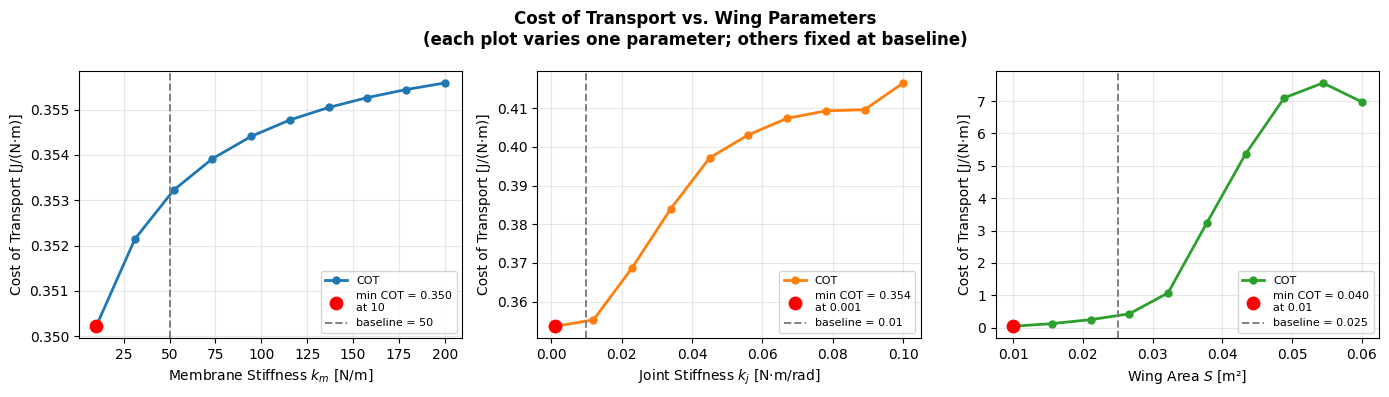


Done! Summary of optima:
  Optimal membrane_stiffness     = 10  (COT=0.3502)
  Optimal joint_stiffness        = 0.001  (COT=0.3536)
  Optimal wing_area              = 0.01  (COT=0.0400)


In [18]:
# ---------------------------------------------------------------------------
# 9.  Entry Point
# ---------------------------------------------------------------------------
 
if __name__ == "__main__":
    print("=" * 60)
    print("  Bat Wing COT Parametric Study")
    print("  Based on: Ramezani et al., IROS 2015")
    print("=" * 60)
 
    rp = RobotParams()
    wp = WingParams()   # baseline
 
    # --- Run baseline simulation -------------------------------------------
    print("\n[1] Baseline simulation (k_m=50, k_j=0.01, S=0.025 m²)...")
    res_base = simulate_flight(wp, rp, n_cycles=5)
    print(f"    COT         = {res_base['COT']:.4f}  J/(N·m)")
    print(f"    Mean Lift   = {res_base['mean_lift']:.4f}  N")
    print(f"    L/D Ratio   = {res_base['LD_ratio']:.2f}")
    print(f"    Mean Power  = {res_base['mean_power']:.4f}  W")
 
    # --- Parameter sweep ---------------------------------------------------
    print("\n[2] Running parameter sweeps (this takes ~1-2 min)...")
    sweep_results = sweep_parameters(n_cycles=4, n_points=10)
 
    fig_sweep = plot_cot_sweep(sweep_results)
 
    print("\nDone! Summary of optima:")
    for param in ["membrane_stiffness", "joint_stiffness", "wing_area"]:
        cot_arr = np.array(sweep_results[param]["COT"])
        vals    = sweep_results[param]["values"]
        idx     = np.argmin(cot_arr)
        print(f"  Optimal {param:22s} = {vals[idx]:.4g}  (COT={cot_arr[idx]:.4f})")

